In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [4]:
data = pd.read_csv('/datasets/Churn.csv')
data.dropna(inplace = True)
display(data.head())
data.drop(['RowNumber', 'CustomerId', 'Surname'], axis = 1, inplace = True)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [5]:
data = pd.get_dummies(data, columns=['Geography', 'Gender'], drop_first = True)
target = data['Exited']
features = data.drop(['Exited'], axis=1)

# Escalamiento
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

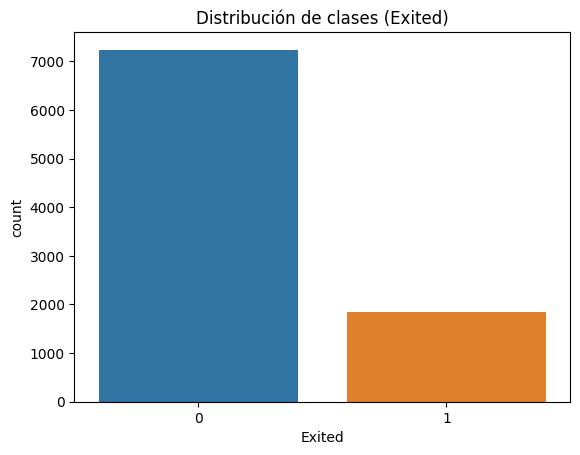


Distribución de clases:
0    0.796062
1    0.203938
Name: Exited, dtype: float64


In [6]:
sns.countplot(x = target)
plt.title('Distribución de clases (Exited)')
plt.show()

print("\nDistribución de clases:")
print(target.value_counts(normalize = True))

In [7]:
features_train, features_test, target_train, target_test = train_test_split(features_scaled, target, test_size = 0.2, random_state = 12345, stratify = target)


--- Modelo Base: Logistic Regression ---
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1448
           1       0.63      0.25      0.36       371

    accuracy                           0.82      1819
   macro avg       0.73      0.61      0.63      1819
weighted avg       0.79      0.82      0.78      1819



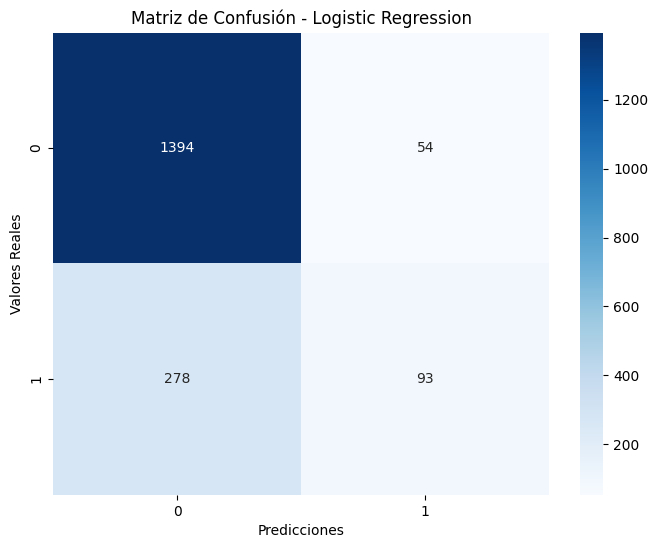

In [8]:
log_model = LogisticRegression()
log_model.fit(features_train, target_train)
predictions_log = log_model.predict(features_test)

print("\n--- Modelo Base: Logistic Regression ---")

print(classification_report(target_test, predictions_log))

cm = confusion_matrix(target_test, predictions_log)
plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Matriz de Confusión - Logistic Regression')
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')
plt.show()




--- Modelo con Oversampling (Random Forest) ---
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      1448
           1       0.69      0.56      0.62       371

    accuracy                           0.86      1819
   macro avg       0.79      0.75      0.77      1819
weighted avg       0.85      0.86      0.85      1819



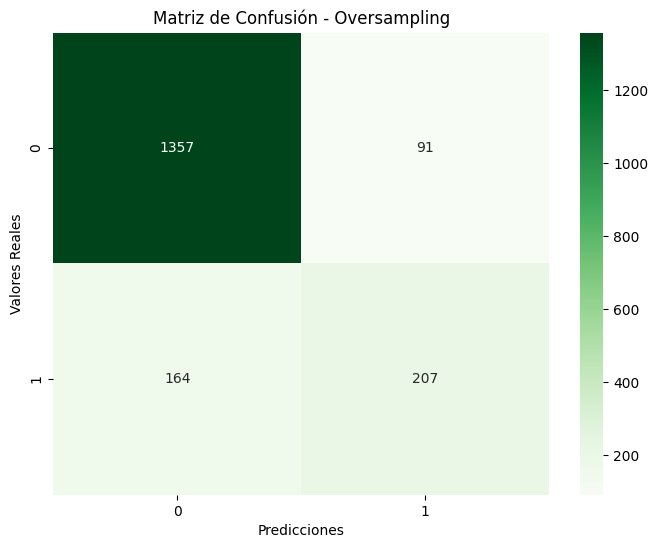

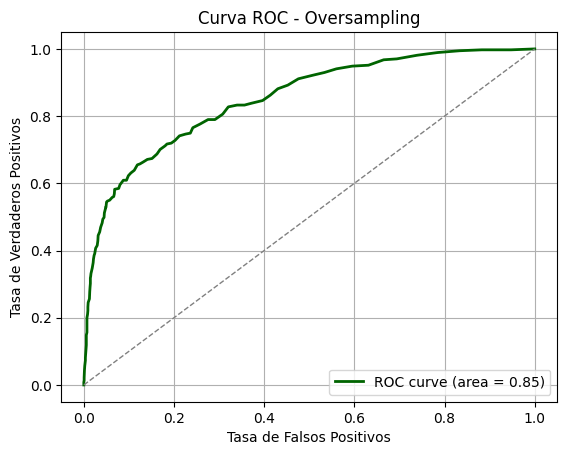

In [12]:

features_train_df = pd.DataFrame(features_train, columns=features.columns)
train_df = features_train_df.copy()
train_df['Exited'] = target_train.values

# Separar clases
class_0 = train_df[train_df['Exited'] == 0]
class_1 = train_df[train_df['Exited'] == 1]

# Oversample clase minoritaria
class_1_oversampled = class_1.sample(len(class_0), replace = True, random_state = 12345)
train_oversampled = pd.concat([class_0, class_1_oversampled]).sample(frac = 1, random_state = 12345)

features_over = train_oversampled.drop('Exited', axis=1)
target_over = train_oversampled['Exited']

# Entrenar modelo
model_over = RandomForestClassifier(random_state = 12345)
model_over.fit(features_over, target_over)
predictions_over = model_over.predict(features_test)

print("\n--- Modelo con Oversampling (Random Forest) ---")
print(classification_report(target_test, predictions_over))

cm = confusion_matrix(target_test, predictions_over)
plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Greens')
plt.title("Matriz de Confusión - Oversampling")
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')
plt.show()

probs_over = model_over.predict_proba(features_test)[:, 1]
fpr_over, tpr_over, _ = roc_curve(target_test, probs_over)
roc_auc_over = auc(fpr_over, tpr_over)

plt.figure()
plt.plot(fpr_over, tpr_over, color='darkgreen', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_over)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Oversampling')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


--- Modelo con Undersampling (Random Forest) ---
              precision    recall  f1-score   support

           0       0.92      0.76      0.83      1448
           1       0.45      0.75      0.56       371

    accuracy                           0.76      1819
   macro avg       0.69      0.76      0.70      1819
weighted avg       0.83      0.76      0.78      1819



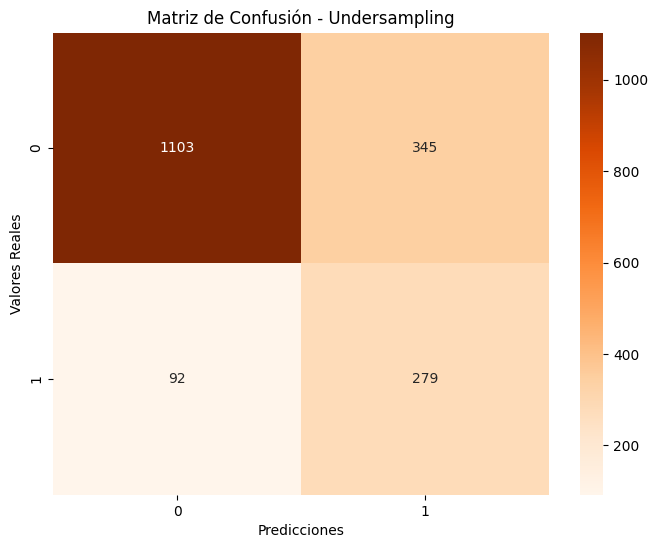

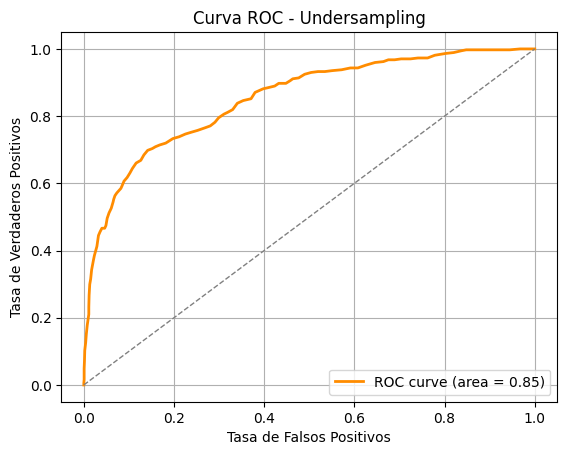

In [10]:

class_0_under = class_0.sample(len(class_1), random_state=42)
train_undersampled = pd.concat([class_0_under, class_1]).sample(frac = 1, random_state = 12345)

features_under = train_undersampled.drop('Exited', axis = 1)
target_under = train_undersampled['Exited']

model_under = RandomForestClassifier(random_state = 12345)
model_under.fit(features_under, target_under)
predictions_under = model_under.predict(features_test)

print("\n--- Modelo con Undersampling (Random Forest) ---")
print(classification_report(target_test, predictions_under))

cm = confusion_matrix(target_test, predictions_under)
plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Oranges')
plt.title("Matriz de Confusión - Undersampling")
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')
plt.show()


probs_under = model_under.predict_proba(features_test)[:, 1]
fpr_under, tpr_under, _ = roc_curve(target_test, probs_under)
roc_auc_under = auc(fpr_under, tpr_under)

plt.figure()
plt.plot(fpr_under, tpr_under, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_under)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Undersampling')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


--- Mejor modelo (GridSearch sobre Oversampling) ---
Parámetros óptimos: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Mejor F1 score (validación cruzada): 0.9386943524506303
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      1448
           1       0.71      0.56      0.63       371

    accuracy                           0.86      1819
   macro avg       0.80      0.75      0.77      1819
weighted avg       0.86      0.86      0.86      1819



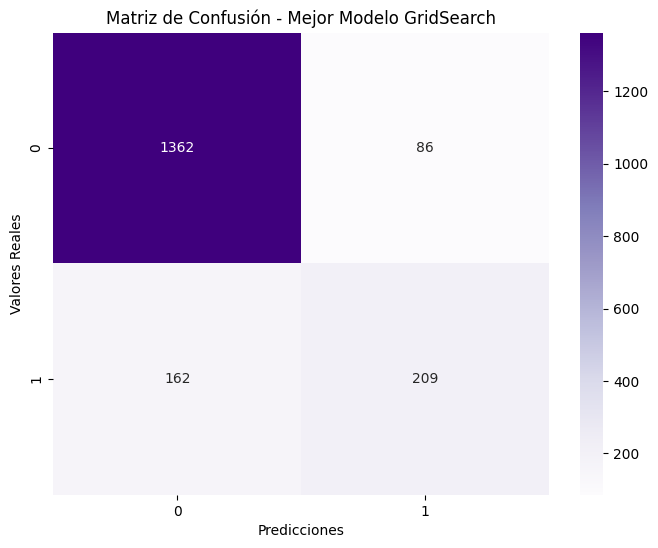

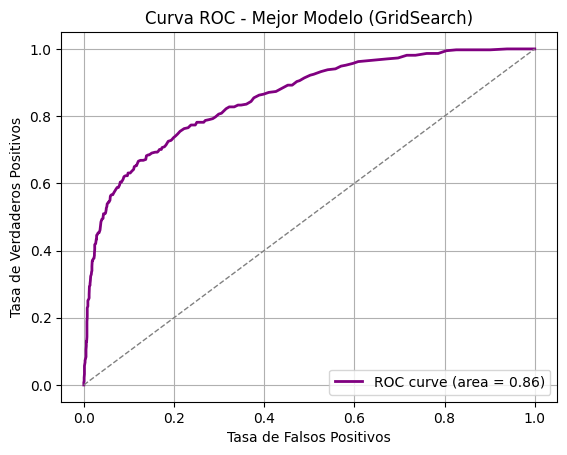

In [11]:

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
}

grid_model = GridSearchCV(RandomForestClassifier(random_state = 12345), param_grid, cv = 3, scoring = 'f1', n_jobs = -1)
grid_model.fit(features_over, target_over)

print("\n--- Mejor modelo (GridSearch sobre Oversampling) ---")
print("Parámetros óptimos:", grid_model.best_params_)
print("Mejor F1 score (validación cruzada):", grid_model.best_score_)

predictions_grid = grid_model.predict(features_test)
print(classification_report(target_test, predictions_grid))
cm = confusion_matrix(target_test, predictions_grid)
plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Purples')
plt.title("Matriz de Confusión - Mejor Modelo GridSearch")
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')
plt.show()

probs_grid = grid_model.predict_proba(features_test)[:, 1]
fpr_grid, tpr_grid, _ = roc_curve(target_test, probs_grid)
roc_auc_grid = auc(fpr_grid, tpr_grid)

plt.figure()
plt.plot(fpr_grid, tpr_grid, color='purple', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_grid)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Mejor Modelo (GridSearch)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Conclusión 

- El proyecto demostró que el desequilibrio de clases es un factor clave en modelos de clasificación como este.

- Un modelo que no trata el desbalance puede parecer preciso, pero no logra identificar adecuadamente a los clientes en riesgo de abandono.

- La técnica de oversampling combinada con Random Forest proporcionó los mejores resultados prácticos, sin necesidad de optimización adicional.

- Esta solución es efectiva, sencilla de implementar y útil para ayudar al banco a identificar a los clientes que podrían abandonar, y así actuar a tiempo con estrategias de retención.